In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### Perguntas a serem respondidas

•	Qual é o percentual de no-shows/cancelamentos em relação ao total de agendamentos? (podemos usar para fazer benchmarking e estabelecer uma meta)

•	Qual o tempo médio entre a data de marcação e a data de cancelamento? (ajuda a criar políticas de multa/depósito)

•	Qual a porcentagem de cancelamentos de última hora? Eles têm alguma característica especifica? (cancelamentos de última hora 
são os mais prejudiciais para a beneficiaria)

•	Cancelamentos ocorrem mais quando o agendamento é feito com muita antecedência ou em cima da hora?

•	Qual o horário/dia da semana com maior incidência de no-show? (útil para ajustar a agenda e promoções nesses horários)

•	Existe sazonalidade: os meses (março–julho) têm diferenças na taxa de cancelamento?

•	É possível prever quais clientes têm maior risco de no-show pelo histórico? 

•	Qual o tempo médio de antecedência que clientes cancelam (48h antes, 7 dias antes)? Isso ajuda a calibrar a política de 
cancelamento e oferecer encaixes.

•	Há diferença no comportamento de cancelamento entre tipos de serviços rápidos (ex: corte) e coloração)?

•	Clientes mais jovens ou mais velhos faltam mais às consultas?

•	Pessoas que recebem SMS faltam menos que as que não recebem?

•	Dias chuvosos aumentam a quantidade de no-shows?

•	A temperatura influencia os cancelamentos?

•	Em épocas (meses) mais quentes a quantidade de consultas no salão de beleza aumenta?

•	Produtos mais caros tem tendencia a ser uma taxa de cancelamento menor?



In [1]:
df = pd.read_csv('dados/refined/cancelamentos_com_clima.csv')

NameError: name 'pd' is not defined

In [15]:
df.head(8)

,UNNAMED: 0,PATIENTID,APPOINTMENTID,GENDER,SCHEDULEDDAY,APPOINTMENTDAY,AGE,NEIGHBOURHOOD,SCHOLARSHIP,HIPERTENSION,...,NO-SHOW,CHAVE_HORA,PRECIPITACAO_MM,TEMP_AR_C,TEMP_MAX_C,TEMP_MIN_C,UMIDADE_RELATIVA,Estacao_Ano,Classificacao_Temp,DATA_HORA_CLIMA
0,0,2.987250e+13,5642903,F,2016-04-29 18:38:08,29/04/2016 00:00:00,62,JARDIM DA PENHA,0,1,...,0,2016-04-29 18:00:00,0.0,15.2,16.5,15.2,77.0,OUTONO,FRIO,2016-04-29 18:00:00
1,1,5.589978e+14,5642503,M,2016-04-29 16:08:27,29/04/2016 00:00:00,56,JARDIM DA PENHA,0,0,...,0,2016-04-29 16:00:00,0.0,16.3,16.3,15.8,72.0,OUTONO,FRIO,2016-04-29 16:00:00
2,2,4.262962e+12,5642549,F,2016-04-29 16:19:04,29/04/2016 00:00:00,62,MATA DA PRAIA,0,0,...,0,2016-04-29 16:00:00,0.0,16.3,16.3,15.8,72.0,OUTONO,FRIO,2016-04-29 16:00:00
3,3,8.679512e+11,5642828,F,2016-04-29 17:29:31,29/04/2016 00:00:00,8,PONTAL DE CAMBURI,0,0,...,0,2016-04-29 17:00:00,0.0,16.4,16.4,16.1,72.0,OUTONO,FRIO,2016-04-29 17:00:00
4,4,8.841186e+12,5642494,F,2016-04-29 16:07:23,29/04/2016 00:00:00,56,JARDIM DA PENHA,0,1,...,0,2016-04-29 16:00:00,0.0,16.3,16.3,15.8,72.0,OUTONO,FRIO,2016-04-29 16:00:00
5,5,9.598513e+13,5626772,F,2016-04-27 08:36:51,29/04/2016 00:00:00,76,REPUBLICA,0,1,...,0,2016-04-27 08:00:00,0.0,20.0,20.1,20.0,76.0,OUTONO,AGRADAVEL,2016-04-27 08:00:00
6,6,7.336882e+14,5630279,F,2016-04-27 15:05:12,29/04/2016 00:00:00,23,GOIABEIRAS,0,0,...,1,2016-04-27 15:00:00,0.0,18.1,18.1,17.4,72.0,OUTONO,AGRADAVEL,2016-04-27 15:00:00
7,7,3.449833e+12,5630575,F,2016-04-27 15:39:58,29/04/2016 00:00:00,39,GOIABEIRAS,0,0,...,1,2016-04-27 15:00:00,0.0,18.1,18.1,17.4,72.0,OUTONO,AGRADAVEL,2016-04-27 15:00:00


In [16]:
df.sample(8)

,UNNAMED: 0,PATIENTID,APPOINTMENTID,GENDER,SCHEDULEDDAY,APPOINTMENTDAY,AGE,NEIGHBOURHOOD,SCHOLARSHIP,HIPERTENSION,...,NO-SHOW,CHAVE_HORA,PRECIPITACAO_MM,TEMP_AR_C,TEMP_MAX_C,TEMP_MIN_C,UMIDADE_RELATIVA,Estacao_Ano,Classificacao_Temp,DATA_HORA_CLIMA
63702,63702,6.711896e+10,5705808,F,2016-05-17 07:31:57,19/05/2016 00:00:00,50,BONFIM,0,1,...,0,2016-05-17 07:00:00,0.0,17.0,17.2,16.9,85.0,OUTONO,AGRADAVEL,2016-05-17 07:00:00
49866,49866,9.546498e+13,5666480,M,2016-05-05 17:10:24,31/05/2016 00:00:00,32,JARDIM DA PENHA,0,0,...,1,2016-05-05 17:00:00,0.0,23.6,25.3,22.9,43.0,OUTONO,AGRADAVEL,2016-05-05 17:00:00
17030,17030,2.413927e+13,5688717,F,2016-05-12 07:35:57,18/05/2016 00:00:00,47,RESISTENCIA,1,0,...,0,2016-05-12 07:00:00,0.0,17.3,17.6,17.2,81.0,OUTONO,AGRADAVEL,2016-05-12 07:00:00
6926,6926,3.663565e+14,5668778,M,2016-05-06 09:43:24,30/05/2016 00:00:00,66,CRUZAMENTO,0,0,...,0,2016-05-06 09:00:00,0.0,15.3,15.5,15.2,86.0,OUTONO,FRIO,2016-05-06 09:00:00
36668,36668,8.824560e+12,5729132,F,2016-05-24 07:15:04,24/05/2016 00:00:00,58,RESISTENCIA,0,1,...,0,2016-05-24 07:00:00,0.0,10.6,11.1,10.6,85.0,OUTONO,FRIO,2016-05-24 07:00:00
14441,14441,9.415472e+13,5663832,F,2016-05-05 10:37:55,10/05/2016 00:00:00,93,MARIA ORTIZ,0,0,...,0,2016-05-05 10:00:00,0.0,15.5,15.5,15.1,83.0,OUTONO,FRIO,2016-05-05 10:00:00
51834,51834,8.656671e+12,5709614,M,2016-05-17 14:06:49,17/05/2016 00:00:00,36,CENTRO,0,0,...,0,2016-05-17 14:00:00,0.0,19.4,19.4,17.5,75.0,OUTONO,AGRADAVEL,2016-05-17 14:00:00
28764,28764,5.712516e+10,5635954,F,2016-04-28 14:20:37,02/05/2016 00:00:00,21,ROMAO,0,0,...,0,2016-04-28 14:00:00,0.0,17.5,18.2,15.9,53.0,OUTONO,AGRADAVEL,2016-04-28 14:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110526 entries, 0 to 110525
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   UNNAMED: 0          110526 non-null  int64  
 1   PATIENTID           110526 non-null  float64
 2   APPOINTMENTID       110526 non-null  int64  
 3   GENDER              110526 non-null  object 
 4   SCHEDULEDDAY        110526 non-null  object 
 5   APPOINTMENTDAY      110526 non-null  object 
 6   AGE                 110526 non-null  int64  
 7   NEIGHBOURHOOD       110526 non-null  object 
 8   SCHOLARSHIP         110526 non-null  int64  
 9   HIPERTENSION        110526 non-null  int64  
 10  DIABETES            110526 non-null  int64  
 11  HANDCAP             110526 non-null  int64  
 12  SMS_RECEIVED        110526 non-null  int64  
 13  NO-SHOW             110526 non-null  int64  
 14  CHAVE_HORA          110526 non-null  object 
 15  PRECIPITACAO_MM     110464 non-null  float64
 16  TEMP_AR_C           110464 non-null  float64
 17  TEMP_MAX_C          110464 non-null  float64
 18  TEMP_MIN_C          110464 non-null  float64
 19  UMIDADE_RELATIVA    110464 non-null  float64
...
 21  Classificacao_Temp  110464 non-null  object 
 22  DATA_HORA_CLIMA     110464 non-null  object 
dtypes: float64(6), int64(9), object(8)
memory usage: 19.4+ MB

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110526 entries, 0 to 110525
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   UNNAMED: 0          110526 non-null  int64  
 1   PATIENTID           110526 non-null  float64
 2   APPOINTMENTID       110526 non-null  int64  
 3   GENDER              110526 non-null  object 
 4   SCHEDULEDDAY        110526 non-null  object 
 5   APPOINTMENTDAY      110526 non-null  object 
 6   AGE                 110526 non-null  int64  
 7   NEIGHBOURHOOD       110526 non-null  object 
 8   SCHOLARSHIP         110526 non-null  int64  
 9   HIPERTENSION        110526 non-null  int64  
 10  DIABETES            110526 non-null  int64  
 11  HANDCAP             110526 non-null  int64  
 12  SMS_RECEIVED        110526 non-null  int64  
 13  NO-SHOW             110526 non-null  int64  
 14  CHAVE_HORA          110526 non-null  object 
 15  PRECIPITACAO_MM     110464 non-nul

In [18]:
df.dtypes

UNNAMED: 0              int64
PATIENTID             float64
APPOINTMENTID           int64
GENDER                 object
SCHEDULEDDAY           object
APPOINTMENTDAY         object
AGE                     int64
NEIGHBOURHOOD          object
SCHOLARSHIP             int64
HIPERTENSION            int64
DIABETES                int64
HANDCAP                 int64
SMS_RECEIVED            int64
NO-SHOW                 int64
CHAVE_HORA             object
PRECIPITACAO_MM       float64
TEMP_AR_C             float64
TEMP_MAX_C            float64
TEMP_MIN_C            float64
UMIDADE_RELATIVA      float64
Estacao_Ano            object
Classificacao_Temp     object
DATA_HORA_CLIMA        object
dtype: object

In [19]:
df.describe()

,UNNAMED: 0,PATIENTID,APPOINTMENTID,AGE,SCHOLARSHIP,HIPERTENSION,DIABETES,HANDCAP,SMS_RECEIVED,NO-SHOW,PRECIPITACAO_MM,TEMP_AR_C,TEMP_MAX_C,TEMP_MIN_C,UMIDADE_RELATIVA
count,110526.000000,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110464.000000,110464.000000,110464.000000,110464.000000,110464.000000
mean,55262.596756,1.474934e+14,5.675304e+06,37.089219,0.098266,0.197248,0.071865,0.022248,0.678971,0.201934,0.195314,18.181411,18.517238,17.579702,74.830098
std,31906.403636,2.560943e+14,7.129544e+04,23.110026,0.297676,0.397923,0.258266,0.161543,0.466874,0.401445,1.075775,4.199052,4.270126,3.917395,14.177089
min,0.000000,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.100000,10.100000,10.000000,22.000000
25%,27631.250000,4.172536e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.200000,15.400000,14.900000,66.000000
50%,55262.500000,3.173184e+13,5.680572e+06,37.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,17.400000,17.700000,17.000000,81.000000
75%,82893.750000,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.800000,21.200000,20.000000,85.000000
max,110526.000000,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,14.400000,33.000000,33.400000,31.500000,94.000000


In [20]:
# Lista de colunas que não são do tipo 'object' (ou seja, são numéricas)
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Cria a matriz de correlação usando APENAS as colunas numéricas
matriz_correlacao = df[colunas_numericas].corr()

# Exibe a matriz (ou crie o heatmap com o código que passei antes)
print(matriz_correlacao)

                  UNNAMED: 0  PATIENTID  APPOINTMENTID       AGE  SCHOLARSHIP  \
UNNAMED: 0          1.000000  -0.004150       0.360568  0.015981     0.000775   
PATIENTID          -0.004150   1.000000       0.004023 -0.004121    -0.002877   
APPOINTMENTID       0.360568   0.004023       1.000000 -0.019106     0.022619   
AGE                 0.015981  -0.004121      -0.019106  1.000000    -0.092463   
SCHOLARSHIP         0.000775  -0.002877       0.022619 -0.092463     1.000000   
HIPERTENSION        0.004834  -0.006436       0.012759  0.504586    -0.019730   
DIABETES            0.013592   0.001608       0.022632  0.292391    -0.024894   
HANDCAP             0.000186  -0.007915       0.014107  0.078032    -0.008587   
SMS_RECEIVED       -0.069943   0.009742       0.256613 -0.012633    -0.001192   
NO-SHOW            -0.017185  -0.001456      -0.162597 -0.060327     0.029134   
PRECIPITACAO_MM     0.134320   0.003342       0.126589  0.013287     0.002303   
TEMP_AR_C          -0.067854

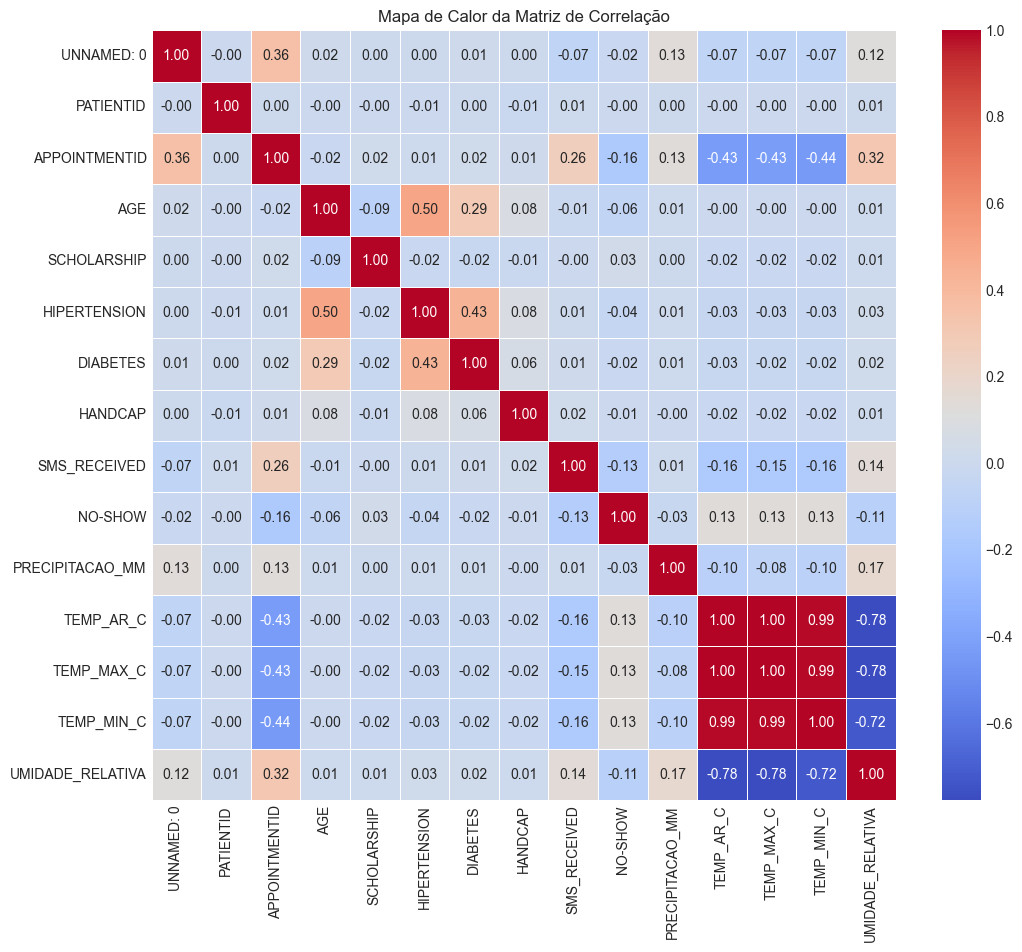

In [21]:

plt.figure(figsize=(12, 10))

# Cria o mapa de calor
# annot=True: mostra os valores de correlação na célula
# cmap: define a paleta de cores (ex: 'coolwarm', 'viridis')
sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f", # Formata os números com 2 casas decimais
    cmap='coolwarm',
    linewidths=.5, # Adiciona linhas entre as células
    cbar=True # Mostra a barra de cores
)

plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()
# Se estiver em um ambiente que não exibe o gráfico (como scripts), você pode salvar:
# plt.savefig('matriz_correlacao_heatmap.png')

ERRO: Certifique-se de que o arquivo 'meu_dataset.csv' existe no caminho correto.

Colunas removidas ou ignoradas: 13
Linhas removidas devido a AGE < 0: 0
Linhas removidas após limpeza de strings em colunas numéricas: 62


C:\Users\ivanm\AppData\Local\Temp\ipykernel_42952\344939305.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


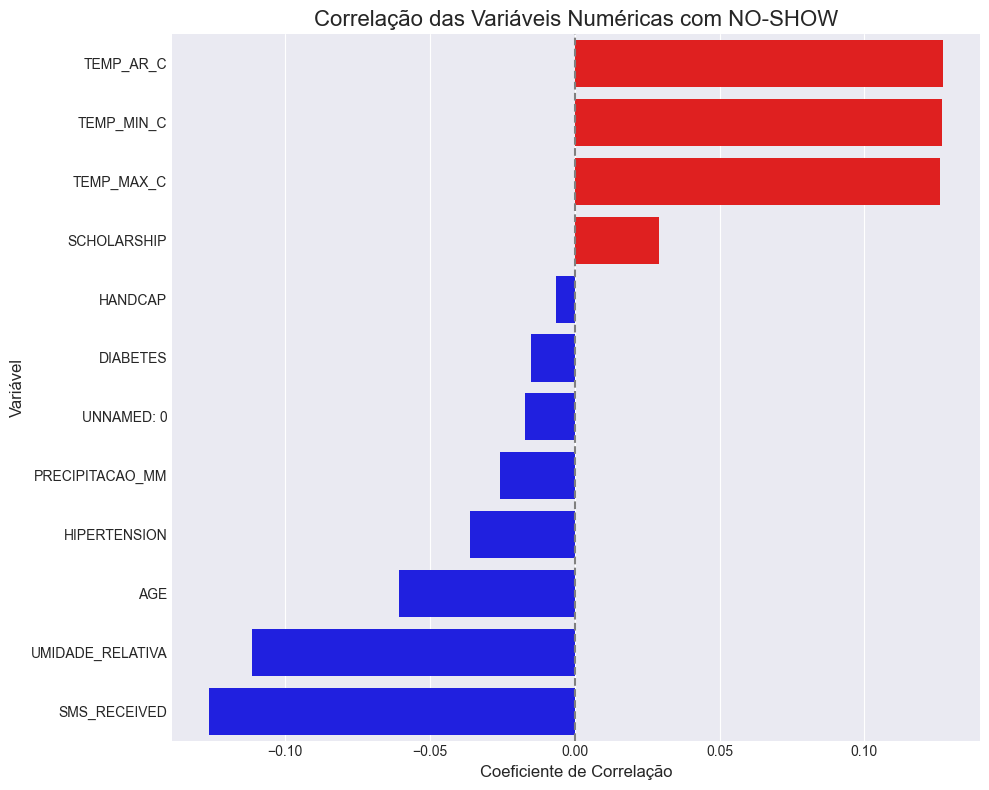

In [22]:
try:
    df = pd.read_csv('meu_dataset.csv')
    print("DataFrame carregado com sucesso.")
except FileNotFoundError:
    print("ERRO: Certifique-se de que o arquivo 'meu_dataset.csv' existe no caminho correto.")
    # Se o df já estiver carregado, comente a linha 'raise'
    # raise 

# ==============================================================================
# 1. REMOÇÃO DE COLUNAS (DROP COLUMNS)
# ==============================================================================
colunas_para_dropar = [
    'ALCOHOLISM',
    'PRESSAO_ESTACAO_MB',
    'PRESSAO_MAX_MB',
    'PRESSAO_MIN_MB',
    'RADIACAO_KJ_M2',
    'TEMP_ORVALHO_C',
    'TEMP_ORVALHO_MAX_C',
    'TEMP_ORVALHO_MIN_C',
    'UMIDADE_MAX',
    'UMIDADE_MIN',
    'VENTO_DIRECAO_GRAUS',
    'VENTO_RAJADA_MAX_MS',
    'VENTO_VELOCIDADE_MS'
]

# Remove as colunas, ignorando aquelas que não existirem ('errors="ignore"')
df.drop(columns=colunas_para_dropar, errors='ignore', inplace=True)
print(f"\nColunas removidas ou ignoradas: {len(colunas_para_dropar)}")

# ==============================================================================
# 2. FILTRO DE LINHAS (DROP ROWS)
# ==============================================================================
linhas_antes = len(df)
# Filtra o DataFrame para manter apenas linhas onde AGE >= 0
df = df[df['AGE'] >= 0].copy()
linhas_depois = len(df)
print(f"Linhas removidas devido a AGE < 0: {linhas_antes - linhas_depois}")

# ==============================================================================
# 3. LIMPEZA DE DADOS NUMÉRICOS (Tratando o erro: 'could not convert string to float: 'F'')
# ==============================================================================
# Força a conversão de todas as colunas numéricas para float, transformando
# qualquer valor não-numérico (como 'F') em NaN
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove as linhas que agora têm NaNs (após a conversão forçada)
df.dropna(inplace=True) 
print(f"Linhas removidas após limpeza de strings em colunas numéricas: {linhas_depois - len(df)}")


# ==============================================================================
# 4. MATRIZ DE CORRELAÇÃO E VISUALIZAÇÃO
# ==============================================================================

# Seleciona apenas as colunas numéricas para o cálculo
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
matriz_correlacao = df[colunas_numericas].corr()

# Seleciona APENAS a correlação com 'NO-SHOW'
correlacoes_no_show = matriz_correlacao['NO-SHOW'].sort_values(ascending=False)

# Remove a correlação de 'NO-SHOW' consigo mesma e colunas de ID
correlacoes_no_show = correlacoes_no_show.drop(
    ['NO-SHOW', 'PATIENTID', 'APPOINTMENTID'], errors='ignore'
)

# 5. Configuração e Geração do Gráfico de Barras Focado
plt.figure(figsize=(10, 8))

# Define cores: vermelho para correlação positiva, azul para negativa
cores = ['red' if x > 0 else 'blue' for x in correlacoes_no_show.values]

# Cria o gráfico de barras
sns.barplot(
    x=correlacoes_no_show.values,
    y=correlacoes_no_show.index,
    palette=cores
)

# Adiciona título, rótulos e linha de referência
plt.title('Correlação das Variáveis Numéricas com NO-SHOW', fontsize=16)
plt.xlabel('Coeficiente de Correlação', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.axvline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

# ==============================================================================
# FIM DO CÓDIGO
# ==============================================================================

ERRO: Certifique-se de que o arquivo existe no caminho correto.

Colunas removidas ou ignoradas: 13
Linhas removidas devido a AGE < 0: 0
Linhas removidas após limpeza: 0


C:\Users\ivanm\AppData\Local\Temp\ipykernel_42952\230009854.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_stats = df.groupby('TEMP_QUARTIL')['NO-SHOW'].mean() * 100


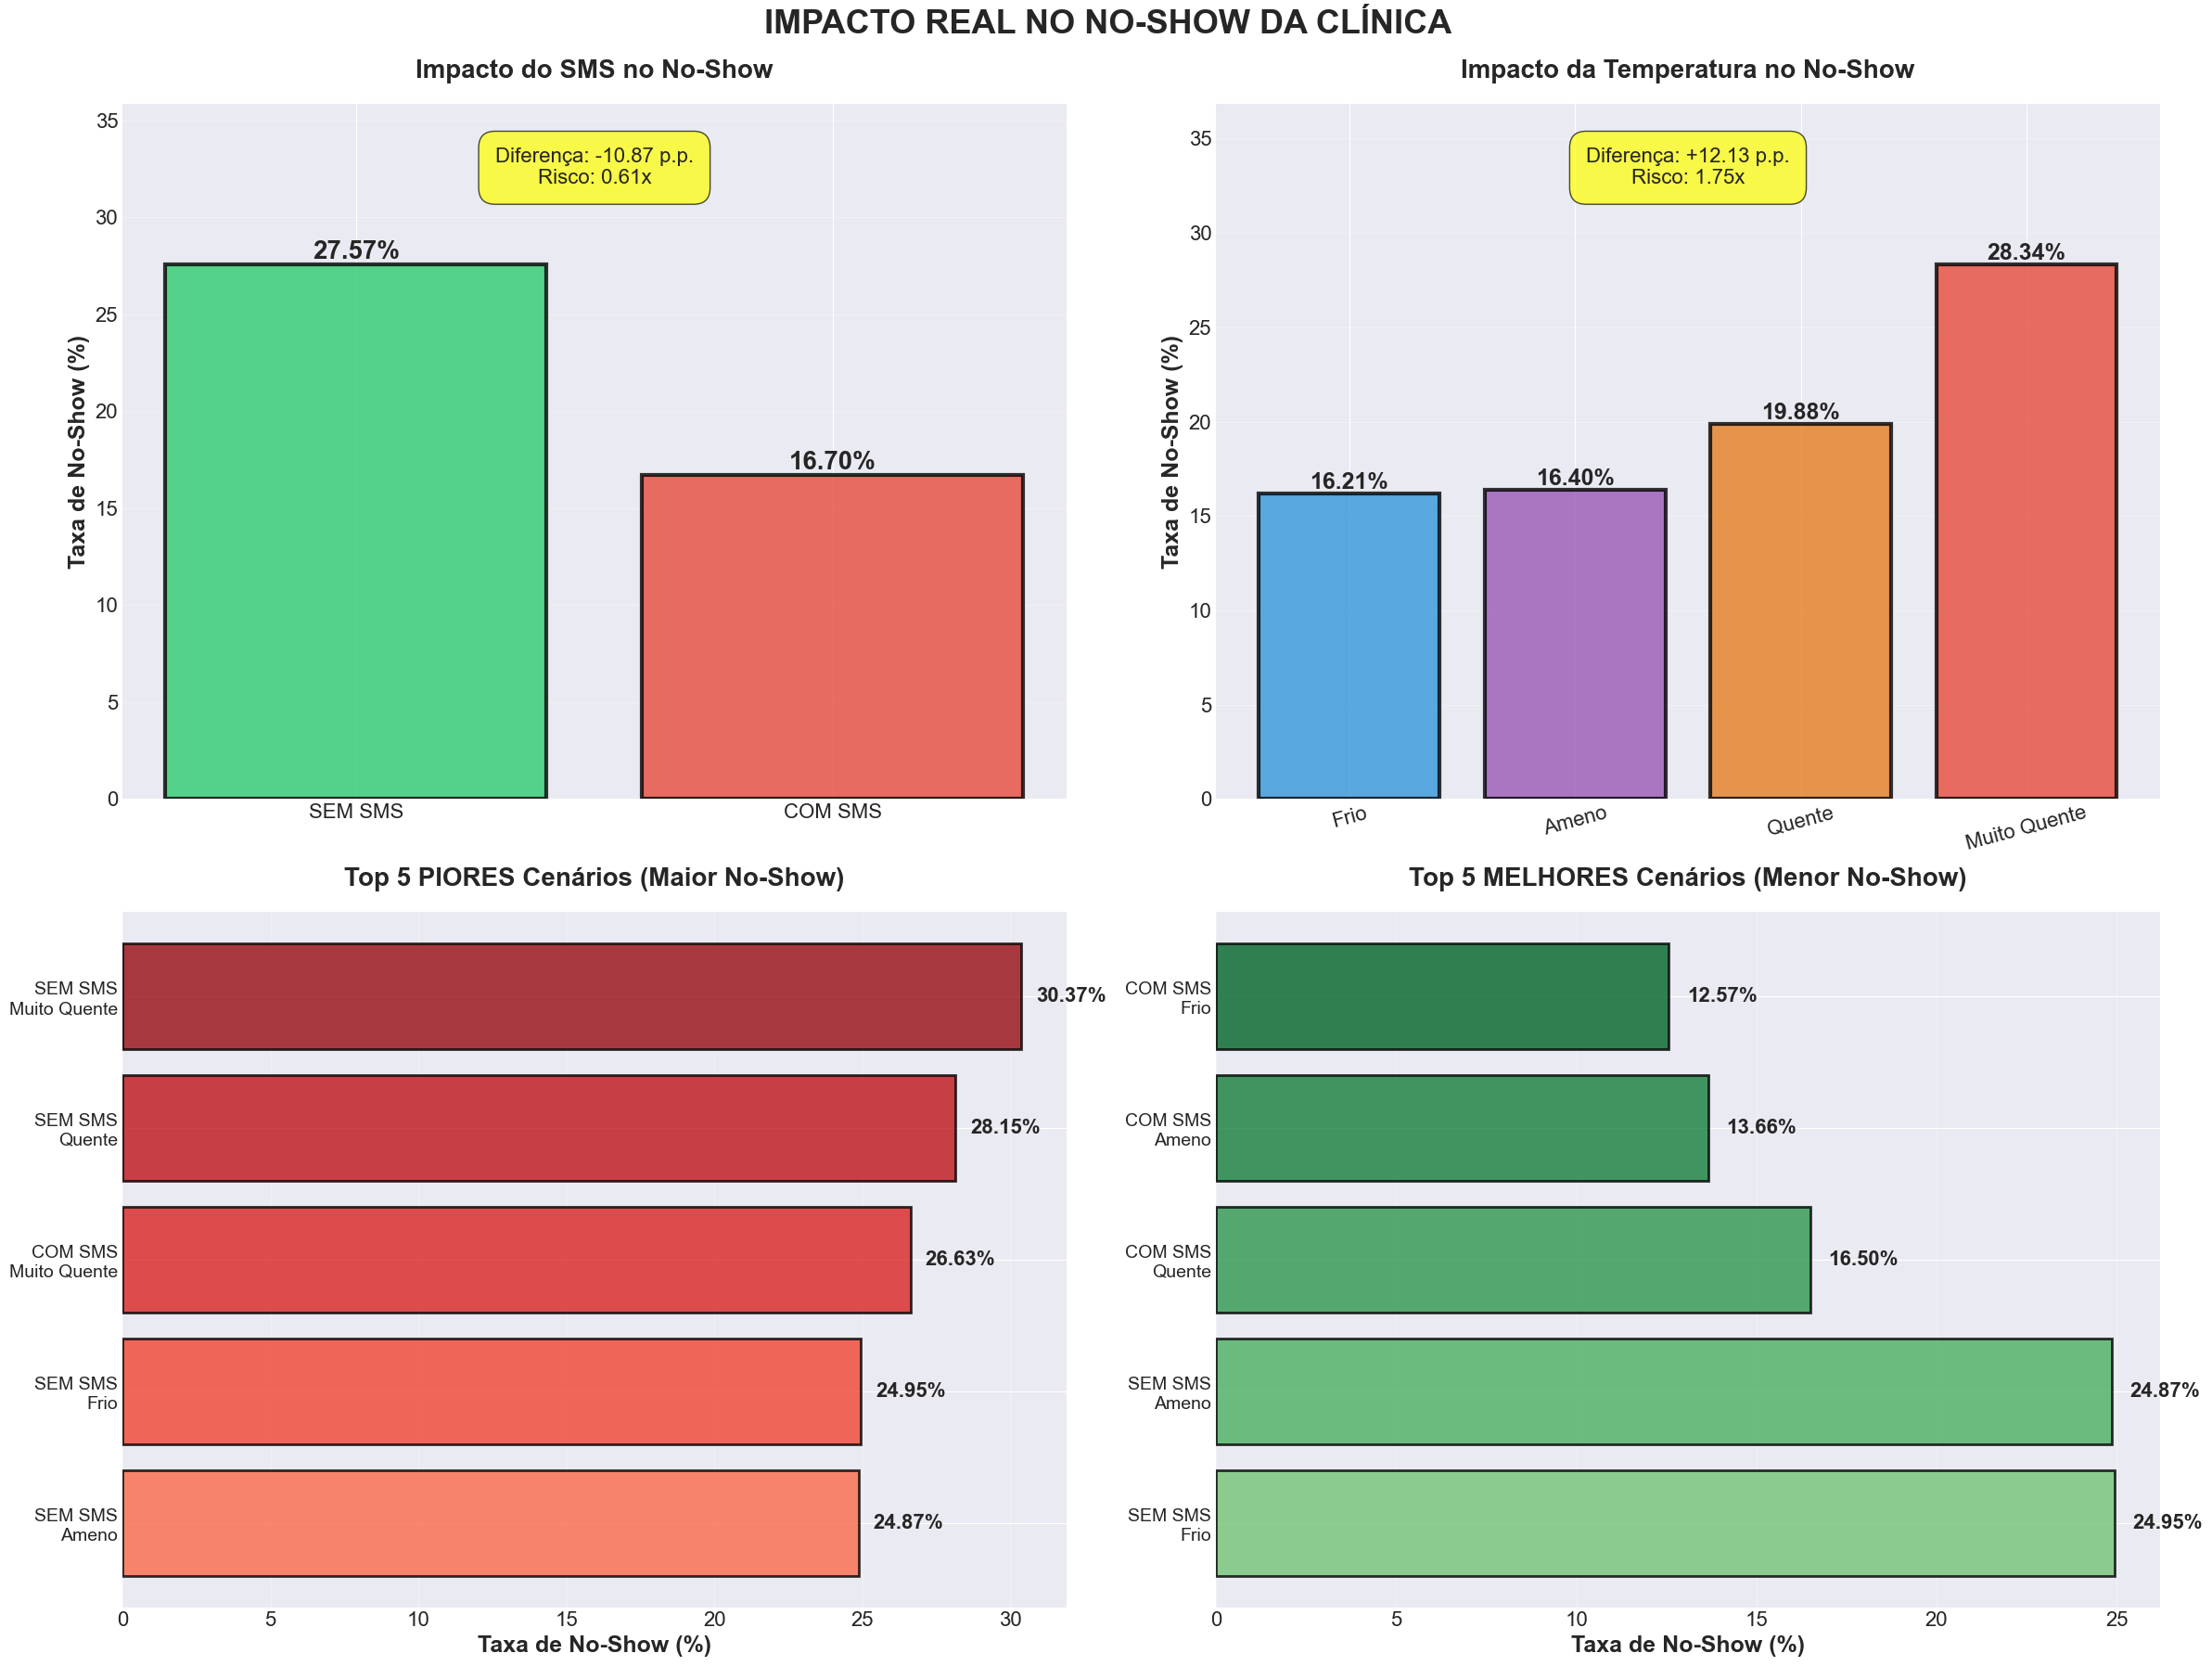


✅ Gráficos gerados com sucesso!
📱 IMPACTO DO RECEBIMENTO DE SMS NO NO-SHOW

📊 Taxa de No-Show:
   • COM SMS:     16.70%
   • SEM SMS:     27.57%
   • DIFERENÇA:   -10.87 pontos percentuais

📈 Volume de Consultas:
   • COM SMS:     75,025 consultas
   • SEM SMS:     35,439 consultas

❌ Faltas Absolutas:
   • COM SMS:     12,530 faltas
   • SEM SMS:     9,770 faltas

⚠️  RISCO RELATIVO: 0.61x
    (Quem recebe SMS tem 0.61x mais chance de faltar)


🌡️  IMPACTO DA TEMPERATURA NO NO-SHOW

📊 Taxa de No-Show por Faixa de Temperatura:
   • Frio            (≈13.4°C): 16.21% | 27,745 consultas
   • Ameno           (≈16.4°C): 16.40% | 27,850 consultas
   • Quente          (≈19.1°C): 19.88% | 27,359 consultas
   • Muito Quente    (≈23.9°C): 28.34% | 27,510 consultas

🔥 DIFERENÇA FRIO vs MUITO QUENTE:
   • Dias Frios:        16.21%
   • Dias Muito Quentes: 28.34%
   • DIFERENÇA:         +12.13 pontos percentuais

⚠️  RISCO RELATIVO: 1.75x
    (Dias muito quentes têm 1.75x mais faltas que dias frio

C:\Users\ivanm\AppData\Local\Temp\ipykernel_42952\230009854.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_stats = df.groupby('TEMP_QUARTIL')['NO-SHOW'].mean() * 100


In [23]:


# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ==============================================================================
# 0. CARREGAMENTO E PRÉ-PROCESSAMENTO
# ==============================================================================
try:
    df = pd.read_csv('dados/refined/cancelamentos_mais_clima.csv')
    print("DataFrame carregado com sucesso.")
except FileNotFoundError:
    print("ERRO: Certifique-se de que o arquivo existe no caminho correto.")

# 1. REMOÇÃO DE COLUNAS
colunas_para_dropar = [
    'ALCOHOLISM', 'PRESSAO_ESTACAO_MB', 'PRESSAO_MAX_MB', 'PRESSAO_MIN_MB',
    'RADIACAO_KJ_M2', 'TEMP_ORVALHO_C', 'TEMP_ORVALHO_MAX_C', 'TEMP_ORVALHO_MIN_C',
    'UMIDADE_MAX', 'UMIDADE_MIN', 'VENTO_DIRECAO_GRAUS', 'VENTO_RAJADA_MAX_MS',
    'VENTO_VELOCIDADE_MS'
]

df.drop(columns=colunas_para_dropar, errors='ignore', inplace=True)
print(f"\nColunas removidas ou ignoradas: {len(colunas_para_dropar)}")

# 2. FILTRO DE LINHAS
linhas_antes = len(df)
df = df[df['AGE'] >= 0].copy()
linhas_depois = len(df)
print(f"Linhas removidas devido a AGE < 0: {linhas_antes - linhas_depois}")

# 3. LIMPEZA DE DADOS NUMÉRICOS
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)
linhas_depois_dropna = len(df)
print(f"Linhas removidas após limpeza: {linhas_depois - linhas_depois_dropna}")

# 4. CRIAÇÃO DA COLUNA TEMP_QUARTIL
if 'TEMP_QUARTIL' not in df.columns:
    df['TEMP_QUARTIL'] = pd.qcut(
        df['TEMP_AR_C'], 
        q=4, 
        labels=['Frio', 'Ameno', 'Quente', 'Muito Quente'], 
        duplicates='drop'
    )

# Cálculos prévios
taxa_noshow_com_sms = df[df['SMS_RECEIVED'] == 1]['NO-SHOW'].mean() * 100
taxa_noshow_sem_sms = df[df['SMS_RECEIVED'] == 0]['NO-SHOW'].mean() * 100

taxa_frio = df[df['TEMP_QUARTIL'] == 'Frio']['NO-SHOW'].mean() * 100
taxa_muito_quente = df[df['TEMP_QUARTIL'] == 'Muito Quente']['NO-SHOW'].mean() * 100
risco_relativo_temp = taxa_muito_quente / taxa_frio
risco_relativo_sms = taxa_noshow_com_sms / taxa_noshow_sem_sms

# Criar GRUPO para análise combinada
df['GRUPO'] = df.apply(lambda row: 
    f"{'COM' if row['SMS_RECEIVED'] == 1 else 'SEM'} SMS + {row['TEMP_QUARTIL']}", 
    axis=1)

analise_combinada = df.groupby('GRUPO').agg({
    'NO-SHOW': ['mean', 'count']
}).round(4)
analise_combinada.columns = ['Taxa_NoShow', 'Quantidade']
analise_combinada['Taxa_NoShow'] = analise_combinada['Taxa_NoShow'] * 100
analise_combinada = analise_combinada.sort_values('Taxa_NoShow', ascending=False)

# ==============================================================================
# 5. GRÁFICOS DE IMPACTO - TAMANHO AMPLIADO
# ==============================================================================
# Criar figura MUITO MAIOR
fig, axes = plt.subplots(2, 2, figsize=(24, 18))
fig.suptitle('IMPACTO REAL NO NO-SHOW DA CLÍNICA', fontsize=26, fontweight='bold', y=0.995)

# GRÁFICO 1: Impacto do SMS
ax1 = axes[0, 0]
categorias_sms = ['SEM SMS', 'COM SMS']
taxas_sms = [taxa_noshow_sem_sms, taxa_noshow_com_sms]
cores_sms = ['#2ecc71', '#e74c3c']

bars1 = ax1.bar(categorias_sms, taxas_sms, color=cores_sms, alpha=0.8, edgecolor='black', linewidth=3)
ax1.set_ylabel('Taxa de No-Show (%)', fontsize=18, fontweight='bold')
ax1.set_title('Impacto do SMS no No-Show', fontsize=20, fontweight='bold', pad=20)
ax1.set_ylim(0, max(taxas_sms) * 1.3)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='both', labelsize=16)

for bar, taxa in zip(bars1, taxas_sms):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{taxa:.2f}%',
             ha='center', va='bottom', fontsize=20, fontweight='bold')

diferenca_sms = taxa_noshow_com_sms - taxa_noshow_sem_sms
ax1.annotate(f'Diferença: {diferenca_sms:+.2f} p.p.\nRisco: {risco_relativo_sms:.2f}x',
             xy=(0.5, max(taxas_sms) * 1.15), ha='center',
             fontsize=16, bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.7))

# GRÁFICO 2: Impacto da Temperatura
ax2 = axes[0, 1]
temp_stats = df.groupby('TEMP_QUARTIL')['NO-SHOW'].mean() * 100
categorias_temp = ['Frio', 'Ameno', 'Quente', 'Muito Quente']
taxas_temp = [temp_stats[cat] for cat in categorias_temp if cat in temp_stats.index]
cores_temp = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c']

bars2 = ax2.bar(categorias_temp[:len(taxas_temp)], taxas_temp, 
                color=cores_temp[:len(taxas_temp)], alpha=0.8, edgecolor='black', linewidth=3)
ax2.set_ylabel('Taxa de No-Show (%)', fontsize=18, fontweight='bold')
ax2.set_title('Impacto da Temperatura no No-Show', fontsize=20, fontweight='bold', pad=20)
ax2.set_ylim(0, max(taxas_temp) * 1.3)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15, labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

for bar, taxa in zip(bars2, taxas_temp):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{taxa:.2f}%',
             ha='center', va='bottom', fontsize=18, fontweight='bold')

diferenca_temp = taxa_muito_quente - taxa_frio
ax2.annotate(f'Diferença: {diferenca_temp:+.2f} p.p.\nRisco: {risco_relativo_temp:.2f}x',
             xy=(1.5, max(taxas_temp) * 1.15), ha='center',
             fontsize=16, bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.7))

# GRÁFICO 3: Top 5 Piores Cenários
ax3 = axes[1, 0]
top_piores = analise_combinada.head(5).sort_values('Taxa_NoShow')
cores_piores = plt.cm.Reds(np.linspace(0.5, 0.9, len(top_piores)))

bars3 = ax3.barh(range(len(top_piores)), top_piores['Taxa_NoShow'], 
                  color=cores_piores, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_yticks(range(len(top_piores)))
ax3.set_yticklabels([grupo.replace(' + ', '\n') for grupo in top_piores.index], fontsize=14)
ax3.set_xlabel('Taxa de No-Show (%)', fontsize=18, fontweight='bold')
ax3.set_title('Top 5 PIORES Cenários (Maior No-Show)', fontsize=20, fontweight='bold', pad=20)
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='x', labelsize=16)

for i, (bar, taxa) in enumerate(zip(bars3, top_piores['Taxa_NoShow'])):
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
             f'{taxa:.2f}%',
             ha='left', va='center', fontsize=16, fontweight='bold')

# GRÁFICO 4: Top 5 Melhores Cenários
ax4 = axes[1, 1]
top_melhores = analise_combinada.tail(5).sort_values('Taxa_NoShow', ascending=False)
cores_melhores = plt.cm.Greens(np.linspace(0.5, 0.9, len(top_melhores)))

bars4 = ax4.barh(range(len(top_melhores)), top_melhores['Taxa_NoShow'], 
                  color=cores_melhores, alpha=0.8, edgecolor='black', linewidth=2)

for i, (bar, taxa) in enumerate(zip(bars4, top_melhores['Taxa_NoShow'])):
    width = bar.get_width()
    ax4.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
             f'{taxa:.2f}%',
             ha='left', va='center', fontsize=16, fontweight='bold')

ax4.set_yticks(range(len(top_melhores)))
ax4.set_yticklabels([grupo.replace(' + ', '\n') for grupo in top_melhores.index], fontsize=14)
ax4.set_xlabel('Taxa de No-Show (%)', fontsize=18, fontweight='bold')
ax4.set_title('Top 5 MELHORES Cenários (Menor No-Show)', fontsize=20, fontweight='bold', pad=20)
ax4.grid(axis='x', alpha=0.3)
ax4.tick_params(axis='x', labelsize=16)

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. SAÍDA FINAL
# ==============================================================================
qtd_com_sms = len(df[df['SMS_RECEIVED'] == 1])
qtd_sem_sms = len(df[df['SMS_RECEIVED'] == 0])
faltas_com_sms = df[(df['SMS_RECEIVED'] == 1) & (df['NO-SHOW'] == 1)].shape[0]
faltas_sem_sms = df[(df['SMS_RECEIVED'] == 0) & (df['NO-SHOW'] == 1)].shape[0]
temp_stats = df.groupby('TEMP_QUARTIL')['NO-SHOW'].mean() * 100

print("\n✅ Gráficos gerados com sucesso!")
print("📱 IMPACTO DO RECEBIMENTO DE SMS NO NO-SHOW")
print("="*60)

print(f"\n📊 Taxa de No-Show:")
print(f"   • COM SMS:     {taxa_noshow_com_sms:.2f}%")
print(f"   • SEM SMS:     {taxa_noshow_sem_sms:.2f}%")
print(f"   • DIFERENÇA:   {taxa_noshow_com_sms - taxa_noshow_sem_sms:+.2f} pontos percentuais")

print(f"\n📈 Volume de Consultas:")
print(f"   • COM SMS:     {qtd_com_sms:,} consultas")
print(f"   • SEM SMS:     {qtd_sem_sms:,} consultas")

print(f"\n❌ Faltas Absolutas:")
print(f"   • COM SMS:     {faltas_com_sms:,} faltas")
print(f"   • SEM SMS:     {faltas_sem_sms:,} faltas")

print(f"\n⚠️  RISCO RELATIVO: {risco_relativo_sms:.2f}x")
print(f"    (Quem recebe SMS tem {risco_relativo_sms:.2f}x mais chance de faltar)")

print("\n\n" + "="*60)
print("🌡️  IMPACTO DA TEMPERATURA NO NO-SHOW")
print("="*60)

print("\n📊 Taxa de No-Show por Faixa de Temperatura:")
for quartil in temp_stats.index:
    taxa = temp_stats[quartil]
    temp_media = df[df['TEMP_QUARTIL'] == quartil]['TEMP_AR_C'].mean()
    qtd = len(df[df['TEMP_QUARTIL'] == quartil])
    print(f"   • {quartil:15s} (≈{temp_media:.1f}°C): {taxa:.2f}% | {qtd:,} consultas")

print(f"\n🔥 DIFERENÇA FRIO vs MUITO QUENTE:")
print(f"   • Dias Frios:        {taxa_frio:.2f}%")
print(f"   • Dias Muito Quentes: {taxa_muito_quente:.2f}%")
print(f"   • DIFERENÇA:         {taxa_muito_quente - taxa_frio:+.2f} pontos percentuais")

print(f"\n⚠️  RISCO RELATIVO: {risco_relativo_temp:.2f}x")
print(f"    (Dias muito quentes têm {risco_relativo_temp:.2f}x mais faltas que dias frios)")

print("\n\n" + "="*60)
print("🔄 ANÁLISE COMBINADA: SMS + TEMPERATURA")
print("="*60)

print("\n📊 Cenários de Maior e Menor Risco:")
print("\n🔴 PIORES CENÁRIOS (maior taxa de no-show):")
print(analise_combinada.head(3).to_string())

print("\n\n🟢 MELHORES CENÁRIOS (menor taxa de no-show):")
print(analise_combinada.tail(3).to_string())

print("\n\n" + "="*60)
print("📋 RESUMO EXECUTIVO")
print("="*60)

print(f"""
✅ IMPACTO DO SMS:
   • Aumenta no-show em {taxa_noshow_com_sms - taxa_noshow_sem_sms:+.2f} p.p.
   • Risco {risco_relativo_sms:.2f}x maior
   • IMPACTO: {'ALTO' if abs(taxa_noshow_com_sms - taxa_noshow_sem_sms) > 5 else 'MODERADO' if abs(taxa_noshow_com_sms - taxa_noshow_sem_sms) > 2 else 'BAIXO'}

🌡️  IMPACTO DA TEMPERATURA:
   • Aumenta no-show em {taxa_muito_quente - taxa_frio:+.2f} p.p. (frio→quente)
   • Risco {risco_relativo_temp:.2f}x maior
   • IMPACTO: {'ALTO' if abs(taxa_muito_quente - taxa_frio) > 5 else 'MODERADO' if abs(taxa_muito_quente - taxa_frio) > 2 else 'BAIXO'}

💡 INTERPRETAÇÃO:
   Correlação de 0.126 parece pequena, mas representa uma diferença
   concreta de {abs(taxa_noshow_com_sms - taxa_noshow_sem_sms):.1f} pontos percentuais na taxa de no-show.
   Em termos práticos: a cada 100 consultas, há {abs(taxa_noshow_com_sms - taxa_noshow_sem_sms):.0f} faltas a mais/menos.
""")

print("="*60)

### Graficos:
- Grafico de linha com: eixo x(tempo), eixo y 1 (temperatura), eixo y 2 (no-shows
) 
- Grafico de barras com atendimentos por dia da semana

### KPIs:
- Velocimetro: % de cancelamentos:

### Filtros: 
- Por dia de semana
-  Para pegar dado por ano, mes e semana
